# 4.1 MultiLDA — 16바이트 동시 프로파일링 · Normal ∥ Masked

## 이 노트북이 답하는 질문

4.0 은 바이트 하나를 프로파일링했다. 키는 16바이트다. **16번 반복하면 되는가?**

된다. 하지만 그러면 수만 장짜리 Trace(트레이스) 배열을 16번 훑는다.
`scalib.modeling.MultiLDA`는 **Trace를 한 번만 읽고** 변수 16개를 동시에 학습한다.

| | |
|---|---|
| 학습 | 타겟별 `/profiling` (동일 예산) |
| 공격 | 타겟별 `/attack` → **키 16바이트 전부 복구** |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 |

## `LDAClassifier` 와의 관계

| | `LDAClassifier` | `MultiLDA` |
|--|-----------------|------------|
| 변수 | 1개 | `nv` 개 |
| POI | 호출자가 잘라서 넘김 | **`pois` 로 변수마다 지정** |
| 라벨 | `(n,)` | `(n, nv)` |
| `predict_proba` | `(n, nc)` | 변수마다 하나씩, **리스트** |

`pois` 에 바이트마다 다른 창을 줄 수 있다는 점이 중요하다 — 1.0 에서 본 대로
바이트별 누설 지점이 서로 다르기 때문이다.

---
## 1. API

| 단계 | 코드 |
|:----:|------|
| 생성 | `mlda = MultiLDA(ncs=[256]*16, ps=[3]*16, pois=pois)` |
| 누적 | `mlda.fit_u(traces, x)` — `traces` 는 **자르지 않은 전체 구간** |
| 완료 | `mlda.solve()` |
| 판정 | `mlda.predict_proba(traces)` → 길이 16 리스트 |

`fit_u` 에 넘기는 `traces` 는 POI 로 자르지 않는다 — `pois` 가 이미 어느 열을 볼지 알고 있다.

> **함정:** 우리는 메모리를 아끼려고 `load_group(..., samples=cols)` 로 **필요한 열만**
> 읽었다. 그러면 `pois` 도 원래 샘플 번호가 아니라 **읽어 온 배열 안에서의 위치**여야 한다.
> `np.searchsorted(cols, window)` 로 옮긴다. 이걸 빠뜨리면 조용히 엉뚱한 열을 학습한다.

> **라벨 shape 규약이 API 마다 다르다.**
>
> | API | 라벨 shape | dtype |
> |-----|-----------|-------|
> | `Ttest` | `(n,)` | `uint16` |
> | `SNR`, `Cpa`, `MultiLDA` | `(n, nv)` | `uint16` |
> | `LDAClassifier` | `(n,)` | `uint16` |
> | `RLDAClassifier` | `(n, nv)` | `uint64` |
> | `RLDAInformationEstimator` | `(n,)` | `uint64` |
>
> Trace(`traces`)는 어디서나 `(n, ns)` `int16`이다.

In [1]:
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from scalib_common import (
    TARGETS, TARGET_IDS, SBOX, HW, AES_BLOCK, sbox_out,
    load_group, load_poi, group_len, dataset_summary, require_target,
)
from scalib.modeling import LDAClassifier, MultiLDA

N_ATK = 500
P_DIM = 3

AVAILABLE = {tid: group_len("profiling", tid) for tid in TARGET_IDS
             if require_target(tid)["dataset"].is_file()}
N_PROF = min(AVAILABLE.values())
print("프로파일링 보유:", {TARGETS[t]["short"]: n for t, n in AVAILABLE.items()})
print("→ 양쪽 모두 %d 장으로 맞춘다." % N_PROF)

sets = {}
for tid in AVAILABLE:
    z = load_poi(tid)
    w = z["poi_windows"].astype(int)
    cols = np.unique(w.ravel())
    prof = load_group("profiling", target=tid, n=N_PROF, samples=cols)
    atk = load_group("attack", target=tid, n=N_ATK, samples=cols)
    loc = [np.searchsorted(cols, w[b]) for b in range(AES_BLOCK)]
    sets[tid] = (prof, atk, loc)
    print("[%s] prof%s  pois 16개, 변수당 %d 샘플"
          % (TARGETS[tid]["short"], prof["t"].shape, len(loc[0])))

TRUE_KEY = np.array(sets[list(sets)[0]][1]["attrs"]["fixed_key"], dtype=np.uint8)

프로파일링 보유: {'Normal': 100000, 'Masked': 100000}
→ 양쪽 모두 100000 장으로 맞춘다.


[Normal] prof(100000, 336)  pois 16개, 변수당 21 샘플


[Masked] prof(100000, 336)  pois 16개, 변수당 21 샘플


---
## 2. Trace 한 번 읽기 vs 16번 읽기

`MultiLDA` 의 값어치를 숫자로 확인한다. 같은 결과를 `LDAClassifier` 16번으로도 낼 수 있지만
Trace 배열을 16번 훑어야 한다.

> **여기서 측정되는 차이는 실제보다 작다.** 우리는 메모리를 아끼려고 이미 POI 열만
> POI 근방 수백 열로 압축해 읽었기 때문에 훑는 비용 자체가 작다. Trace 전체를 들고 도는
> 일반적인 상황에서는 격차가 훨씬 커진다. 아래 숫자는 "방향" 으로 읽는다.

In [2]:
GUESS = np.arange(256, dtype=np.uint8)


def key_logprob(proba, plaintext_byte):
    """(n, 256) 중간값 확률 → (256,) 키 후보 누적 로그확률 (벡터화)."""
    lp = np.log(np.maximum(proba, 1e-300))
    v = SBOX[np.bitwise_xor(plaintext_byte[:, None], GUESS[None, :])]
    return np.take_along_axis(lp, v, axis=1).sum(axis=0)


probas, timing = {}, {}
for tid in sets:
    prof, atk, loc = sets[tid]
    y = sbox_out(prof["p"], prof["k"]).astype(np.uint16)      # (n, 16)

    t0 = time.time()
    mlda = MultiLDA(ncs=[256] * AES_BLOCK, ps=[P_DIM] * AES_BLOCK, pois=loc)
    mlda.fit_u(np.ascontiguousarray(prof["t"]), y)
    mlda.solve()
    pr = mlda.predict_proba(np.ascontiguousarray(atk["t"]))
    t_multi = time.time() - t0

    t0 = time.time()
    for b in range(AES_BLOCK):
        lda = LDAClassifier(nc=256, p=P_DIM)
        lda.fit_u(np.ascontiguousarray(prof["t"][:, loc[b]]), y[:, b])
        lda.solve()
        lda.predict_proba(np.ascontiguousarray(atk["t"][:, loc[b]]))
    t_loop = time.time() - t0

    probas[tid] = pr
    timing[tid] = (t_multi, t_loop)
    print("[%-8s] MultiLDA %.1fs   LDA 16회 %.1fs   (%.1f배)"
          % (TARGETS[tid]["short"], t_multi, t_loop, t_loop / max(t_multi, 1e-9)))
    print("           predict_proba 반환: 길이 %d 리스트, 각 %s"
          % (len(pr), pr[0].shape))

[Normal  ] MultiLDA 0.1s   LDA 16회 0.5s   (7.9배)
           predict_proba 반환: 길이 16 리스트, 각 (500, 256)


[Masked  ] MultiLDA 0.1s   LDA 16회 0.5s   (6.3배)
           predict_proba 반환: 길이 16 리스트, 각 (500, 256)


---
## 3. 키 16바이트 복구

변수마다 확률을 받아, 4.0 과 같은 방식으로 로그확률을 누적한다.

In [3]:
ranks = {}
for tid in probas:
    _, atk, _ = sets[tid]
    r = np.array([
        int(np.where(np.argsort(-key_logprob(probas[tid][b], atk["p"][:, b]))
                     == TRUE_KEY[b])[0][0])
        for b in range(AES_BLOCK)])
    ranks[tid] = r
    recovered = np.array([int(np.argmax(key_logprob(probas[tid][b], atk["p"][:, b])))
                          for b in range(AES_BLOCK)], dtype=np.uint8)
    print("=== %s ===" % TARGETS[tid]["short"])
    print("  복구: " + " ".join("%02x" % b for b in recovered))
    print("  정답: " + " ".join("%02x" % b for b in TRUE_KEY))
    print("  바이트별 순위: %s" % r.tolist())
    print("  === %d / 16 복구, 평균 순위 %.1f ===" % (int((r == 0).sum()), r.mean()))
    print()

if len(ranks) == 2:
    print("[비교] 같은 학습 예산(%d장)·같은 공격 장수(%d장)" % (N_PROF, N_ATK))
    for tid in ranks:
        print("  %-8s %2d/16 복구, 평균 순위 %6.1f"
              % (TARGETS[tid]["short"], int((ranks[tid] == 0).sum()), ranks[tid].mean()))

=== Normal ===
  복구: 2f 6b 07 31 d3 e2 66 7f 26 85 42 9f 35 dc 5d d1
  정답: 2f 6b 07 31 d3 e2 66 7f 26 85 42 9f 35 dc 5d d1
  바이트별 순위: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  === 16 / 16 복구, 평균 순위 0.0 ===

=== Masked ===
  복구: 55 78 91 13 1f c9 d9 99 be 5d d2 21 ef bf 5d c9
  정답: 2f 6b 07 31 d3 e2 66 7f 26 85 42 9f 35 dc 5d d1
  바이트별 순위: [7, 220, 229, 255, 82, 108, 110, 145, 203, 11, 72, 109, 185, 138, 0, 215]
  === 1 / 16 복구, 평균 순위 130.6 ===

[비교] 같은 학습 예산(100000장)·같은 공격 장수(500장)
  Normal   16/16 복구, 평균 순위    0.0
  Masked    1/16 복구, 평균 순위  130.6


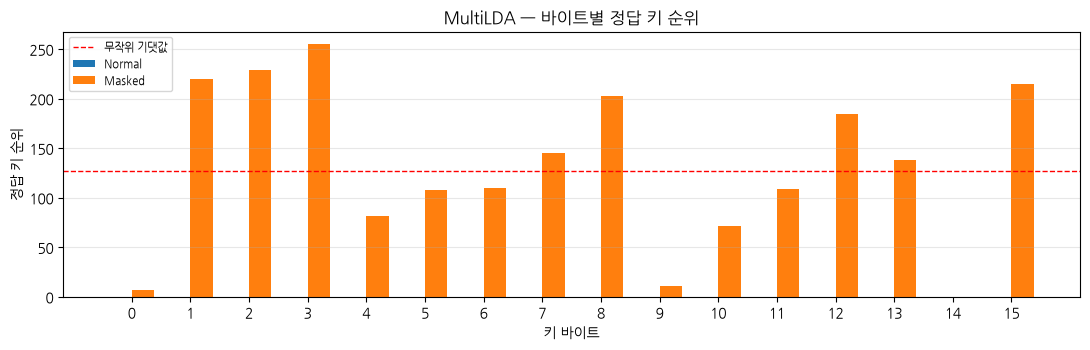

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.6))
x = np.arange(AES_BLOCK)
w = 0.38 if len(ranks) == 2 else 0.6
for i, tid in enumerate(ranks):
    ax.bar(x + (i - (len(ranks) - 1) / 2) * w, ranks[tid], w,
           label=TARGETS[tid]["short"])
ax.axhline(127.5, color="r", ls="--", lw=1, label="무작위 기댓값")
ax.set_xticks(x); ax.set_xlabel("키 바이트"); ax.set_ylabel("정답 키 순위")
ax.set_title("MultiLDA — 바이트별 정답 키 순위")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout(); plt.show()

---
## 4. 몇 장이면 16바이트가 다 맞는가 — CPA 와 비교

3.0 CPA 는 같은 `/attack` 데이터에서 Normal 을 200장으로 복구했다.
프로파일링은 **미리 수만 개의 Trace를 쓴 대가로** 공격 시 훨씬 적은 트레이스 수로 끝난다.
그 대가가 실제로 얼마나 돌아오는지 본다.

[Normal  ] 1장:3 2장:8 3장:10 5장:16 10장:16 25장:16 50장:16 100장:16 250장:16 500장:16
[Masked  ] 1장:0 2장:0 3장:0 5장:0 10장:1 25장:0 50장:0 100장:1 250장:1 500장:1


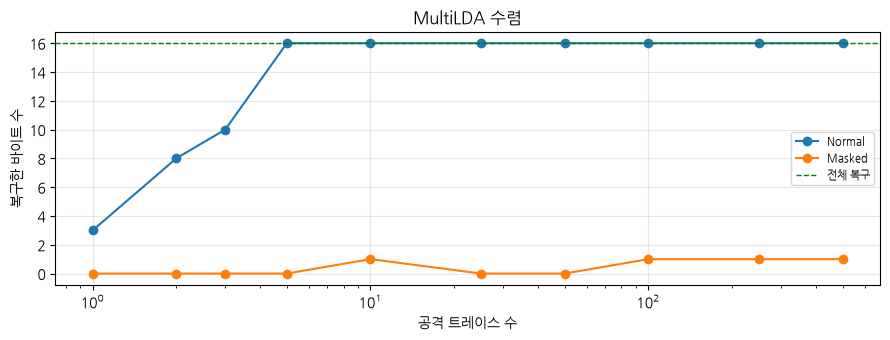

[Normal  ] 16바이트 전부 복구에 필요한 공격 장수: 5
[Masked  ] 16바이트 전부 복구에 필요한 공격 장수: 이 범위에서 실패

3.0 CPA 는 Normal 을 200장으로 복구했다. 프로파일링을 마친 공격자는
그보다 훨씬 적은 장수로 끝낸다 — 이것이 사전 접근 권한의 값어치다.
Masked 는 프로파일링을 해도 장수를 늘려도 올라오지 않는다.


In [5]:
STEPS = [1, 2, 3, 5, 10, 25, 50, 100, 250, 500]

curve = {}
for tid in probas:
    _, atk, _ = sets[tid]
    hits = []
    for m in STEPS:
        m = min(m, atk["t"].shape[0])
        got = sum(int(np.argmax(key_logprob(probas[tid][b][:m], atk["p"][:m, b]))
                      == TRUE_KEY[b]) for b in range(AES_BLOCK))
        hits.append(got)
    curve[tid] = hits
    print("[%-8s] " % TARGETS[tid]["short"]
          + " ".join("%d장:%d" % (s, h) for s, h in zip(STEPS, hits)))

fig, ax = plt.subplots(figsize=(9, 3.5))
for tid in curve:
    ax.plot(STEPS, curve[tid], "o-", label=TARGETS[tid]["short"])
ax.axhline(16, color="g", ls="--", lw=1, label="전체 복구")
ax.set_xscale("log"); ax.set_xlabel("공격 트레이스 수")
ax.set_ylabel("복구한 바이트 수"); ax.set_title("MultiLDA 수렴")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

first = {}
for tid in curve:
    ok = [s for s, h in zip(STEPS, curve[tid]) if h == AES_BLOCK]
    first[tid] = ok[0] if ok else None
    print("[%-8s] 16바이트 전부 복구에 필요한 공격 장수: %s"
          % (TARGETS[tid]["short"], first[tid] if first[tid] else "이 범위에서 실패"))
print()
print("3.0 CPA 는 Normal 을 200장으로 복구했다. 프로파일링을 마친 공격자는")
print("그보다 훨씬 적은 장수로 끝낸다 — 이것이 사전 접근 권한의 값어치다.")
print("Masked 는 프로파일링을 해도 장수를 늘려도 올라오지 않는다.")

---
## 5. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 여러 변수를 **Trace 한 번 읽기로** 동시에 프로파일링한다 |
| API | `MultiLDA(ncs, ps, pois)` → `fit_u(traces, x)` → `solve()` → `predict_proba(traces)` |
| `pois` | 변수마다 볼 열 인덱스. 바이트별 누설 위치가 다르므로 필요하다 |
| `x` | `(n, nv)` `uint16` — **2차원**. `LDAClassifier` 와 다르다 |
| 출력 | 길이 `nv` 리스트, 각 `(n, nc)` |

### 이 Dataset(데이터셋)에서 관측한 것

- Normal: 공격 Trace 몇 개면 16바이트를 모두 복구한다. CPA보다 두 자릿수 적은 트레이스 수다.
- Masked: 같은 예산·같은 절차로 아무것도 복구되지 않는다.
  4.0 의 결론과 같다 — 프로파일링의 강점은 "가정을 측정으로 바꾸는" 것이지
  **없는 정보를 만들어 내지는 못한다.**

### 실패 시 점검

1. `fit_u`에 POI로 자른 Trace를 넣으면 안 된다. `pois` 인덱스와 어긋난다.
2. `samples=` 로 열을 골라 읽었다면 `pois` 를 `searchsorted` 로 옮겼는지 확인한다.
3. 특정 바이트만 계속 틀린다 → 그 바이트의 POI 를 1.0 에서 다시 확인한다.
4. `solve()` 를 빠뜨리면 `predict_proba` 가 실패한다.

다음: `4.2.RLDA.ipynb` — 회귀 기반 모델과 정보량 추정.